In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
base_dir = Path('/mnt/raidbio2/extstud/praktikum/genprakt-ws25/sc_data')

counts_200_bp = pd.read_csv(base_dir / 'ref_last200_bp_counts.tsv', sep='\t', header=None, names=['transcript_id', 'count'])
counts_100_bp = pd.read_csv(base_dir / 'ref_last100_bp_counts.tsv', sep='\t', header=None, names=['transcript_id', 'count'])
counts_both = pd.merge(counts_100_bp, counts_200_bp, on='transcript_id', suffixes=('_100bp', '_200bp'),how='outer')
print(counts_100_bp.shape)
print(counts_200_bp.shape)
print(counts_both.shape)
counts_both['count_100bp'] = counts_both['count_100bp'].fillna(0)
counts_both.head()

ModuleNotFoundError: No module named 'pandas'

ValueError: provided too many kwargs, can only pass {'basex', 'subsx', nonposx'} or {'basey', 'subsy', nonposy'}.  You passed {'base': 2}

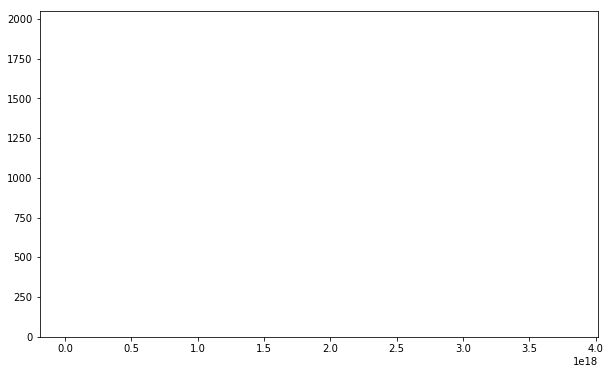

In [14]:
fig = plt.figure(figsize=(10, 6))
bins = np.logspace(np.log2(counts_200_bp['count'].min()), np.log2(counts_200_bp['count'].max()), 100)
plt.hist(counts_200_bp['count'], bins=bins, color='blue', alpha=0.7)
plt.xscale('log', base=2)
plt.title('Distribution of Counts in Last 200 bp')
plt.xlabel('Count (log scale)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

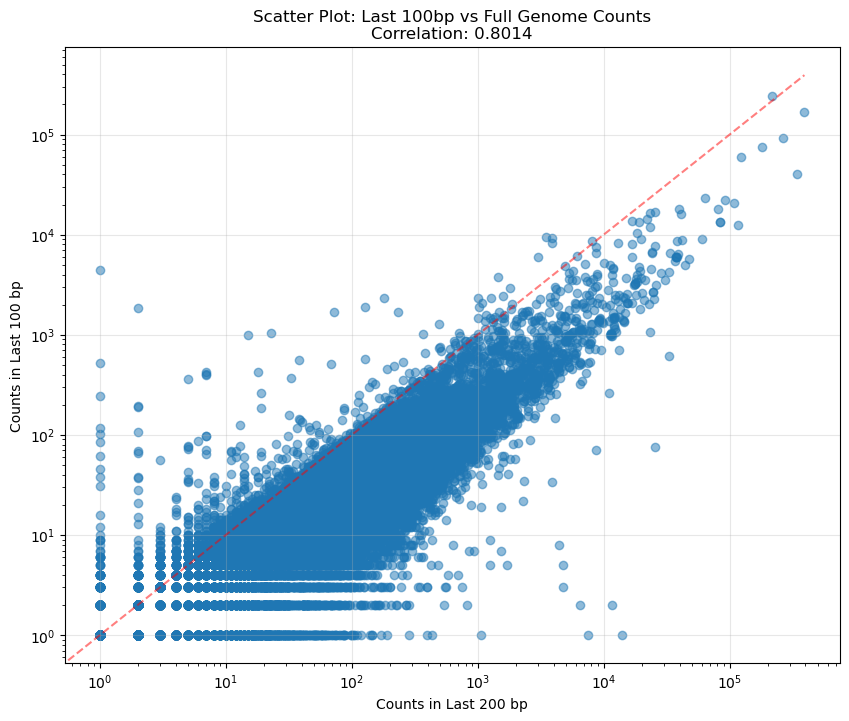

In [ ]:
fig = plt.figure(figsize=(10, 8))
plt.scatter(counts_both['count_200bp'], counts_both['count_100bp'], alpha=0.5)
correlation = counts_both[['count_200bp', 'count_100bp']].corr().iloc[0, 1]
plt.xlabel('Counts in Last 200 bp')
plt.ylabel('Counts in Last 100 bp')
plt.xscale('log', base=10)
plt.yscale('log', base=10)
plt.title('Scatter Plot of Counts in Last 200 bp vs Last 100 bp')
plt.grid(True, alpha=0.3)
plt.title(f'Scatter Plot: Last 100bp vs Full Genome Counts\nCorrelation: {correlation:.4f}')
# Add diagonal reference line
min_val = min(counts_both['count_200bp'].min(), counts_both['count_100bp'].min())
max_val = max(counts_both['count_200bp'].max(), counts_both['count_100bp'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
plt.show()

In [ ]:
fullgenome_counts = pd.read_csv(base_dir / "full_genome_transcript_counts.txt", sep='\t', comment='#')

fullgenome_counts.rename(columns={fullgenome_counts.columns[-1]: 'counts'}, inplace=True)
fullgenome_counts = fullgenome_counts[['Geneid', 'counts']]
fullgenome_counts = fullgenome_counts[(fullgenome_counts['counts'] > 200) & (fullgenome_counts['counts'] < 250)]

fullgenome_counts.head(20)


PermissionError: [Errno 13] Permission denied: '/mnt/raidbio2/extstud/praktikum/genprakt-ws25/sc_data/full_genome_transcript_counts.txt'

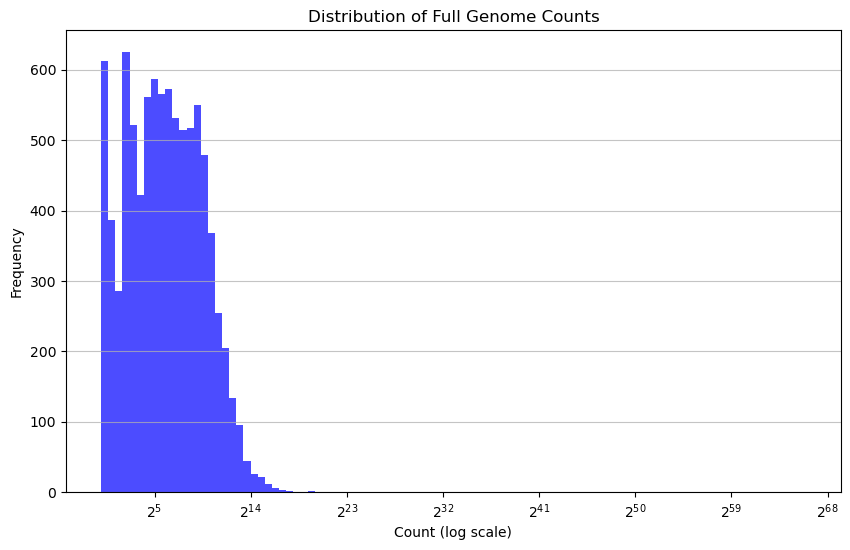

In [ ]:
fig = plt.figure(figsize=(10, 6))
bins = np.logspace(np.log2(fullgenome_counts['counts'].min() + 1), np.log2(fullgenome_counts['counts'].max()), 100)
plt.hist(fullgenome_counts['counts'], bins=bins, color='blue', alpha=0.7)
plt.xscale('log', base=2)
plt.title('Distribution of Full Genome Counts')
plt.xlabel('Count (log scale)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Pearson Correlation: 0.5590


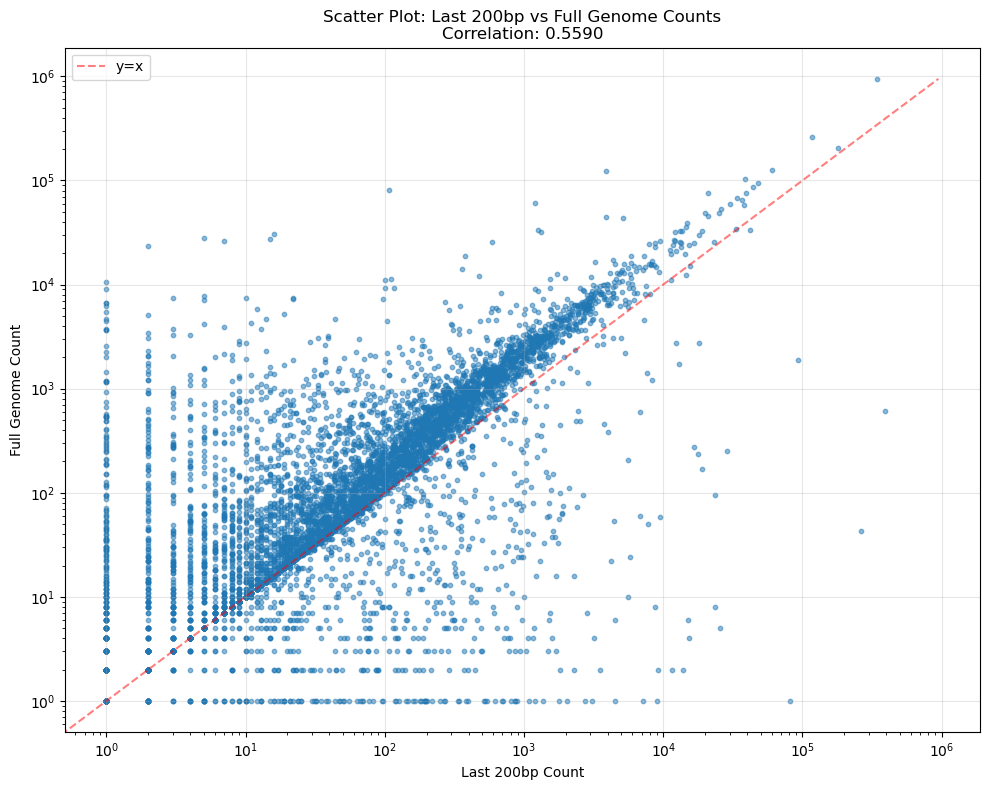

In [ ]:
# Merge the two datasets
merged = counts_200_bp.merge(fullgenome_counts[['Geneid', 'counts']], 
                              left_on='transcript_id', 
                              right_on='Geneid', 
                              how='inner')

# Calculate correlation
correlation = merged['count'].corr(merged['counts'])
print(f'Pearson Correlation: {correlation:.4f}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged['count'], merged['counts'], alpha=0.5, s=10)
ax.set_xlabel('Last 200bp Count')
ax.set_ylabel('Full Genome Count')
ax.set_title(f'Scatter Plot: Last 200bp vs Full Genome Counts\nCorrelation: {correlation:.4f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
min_val = min(merged['count'].min(), merged['counts'].min())
max_val = max(merged['count'].max(), merged['counts'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
ax.legend()

plt.tight_layout()
plt.show()

Pearson Correlation: 0.1867


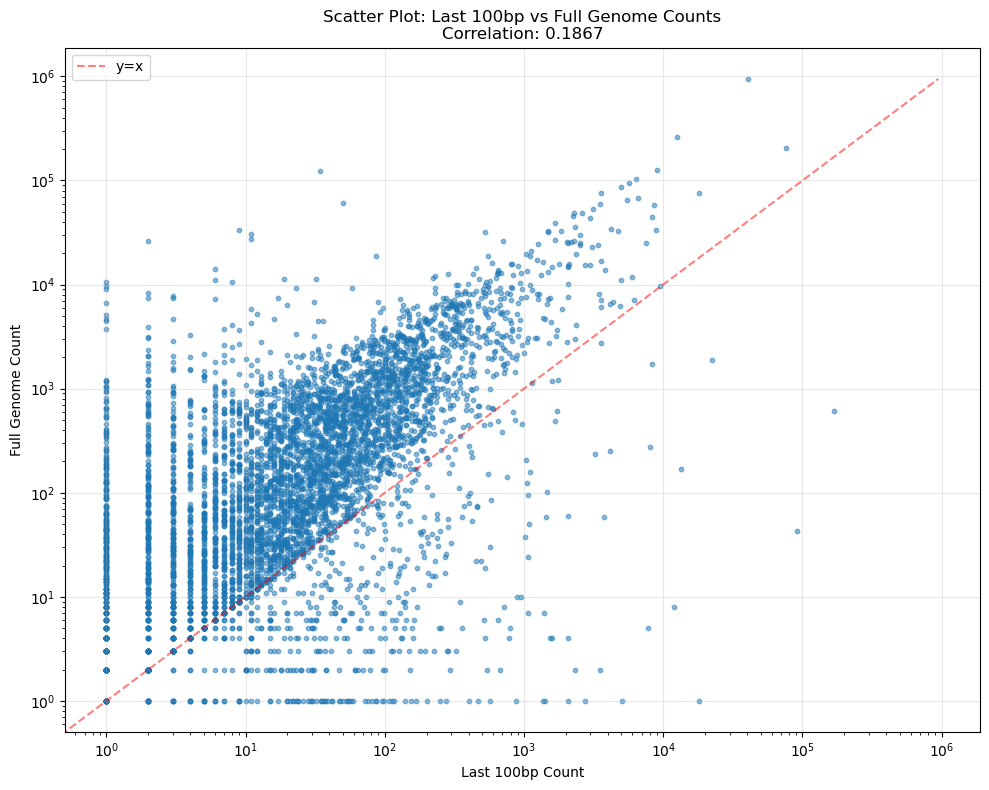

In [ ]:
# Merge the two datasets
merged = counts_100_bp.merge(fullgenome_counts[['Geneid', 'counts']], 
                              left_on='transcript_id', 
                              right_on='Geneid', 
                              how='inner')

# Calculate correlation
correlation = merged['count'].corr(merged['counts'])
print(f'Pearson Correlation: {correlation:.4f}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(merged['count'], merged['counts'], alpha=0.5, s=10)
ax.set_xlabel('Last 100bp Count')
ax.set_ylabel('Full Genome Count')
ax.set_title(f'Scatter Plot: Last 100bp vs Full Genome Counts\nCorrelation: {correlation:.4f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Add diagonal reference line
min_val = min(merged['count'].min(), merged['counts'].min())
max_val = max(merged['count'].max(), merged['counts'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='y=x')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd 

star_last_k_counts = pd.read_csv('../data/coverage_tsv/all_k_counts.tsv', sep='\t', header = 0)
star_last_k_counts.head()



,transcript_id,k100_count,k200_count,k300_count,k400_count,k500_count,k600_count,k700_count,k800_count,k900_count,...,k1100_count,k1200_count,k1300_count,k1400_count,k1500_count,k1600_count,k1700_count,k1800_count,k1900_count,k2000_count
0,ENSSSCT00000000003,724,834,934,1034,36,136,35,90,33,...,2,23,123,223,323,27,127,52,152,252
1,ENSSSCT00000000004,6334,34215,50440,52847,72,172,272,30,47,...,87,21,39,40,20,44,144,70,170,16
2,ENSSSCT00000000006,373,1554,2746,2746,2746,2746,2746,2746,2746,...,2746,2746,3513,4245,4730,4730,5007,15557,52259,80736
3,ENSSSCT00000000007,0,153,153,153,153,153,153,153,153,...,153,153,153,153,153,153,153,153,153,153
4,ENSSSCT00000000008,8818,59661,118650,140631,499,43,143,98,30,...,3,103,80,73,7,107,135,135,135,135


Loaded last_100_bp.tsv
Loaded last_200_bp.tsv
Loaded last_300_bp.tsv
Loaded last_400_bp.tsv
Loaded last_500_bp.tsv
Loaded last_600_bp.tsv
Loaded last_700_bp.tsv
Loaded last_800_bp.tsv
Loaded last_900_bp.tsv
Loaded last_1000_bp.tsv
Loaded last_1100_bp.tsv
Loaded last_1200_bp.tsv
Loaded last_1300_bp.tsv
Loaded last_1400_bp.tsv
Loaded last_1500_bp.tsv
Loaded last_1600_bp.tsv
Loaded last_1700_bp.tsv
Loaded last_1800_bp.tsv
Loaded last_1900_bp.tsv
Loaded last_2000_bp.tsv


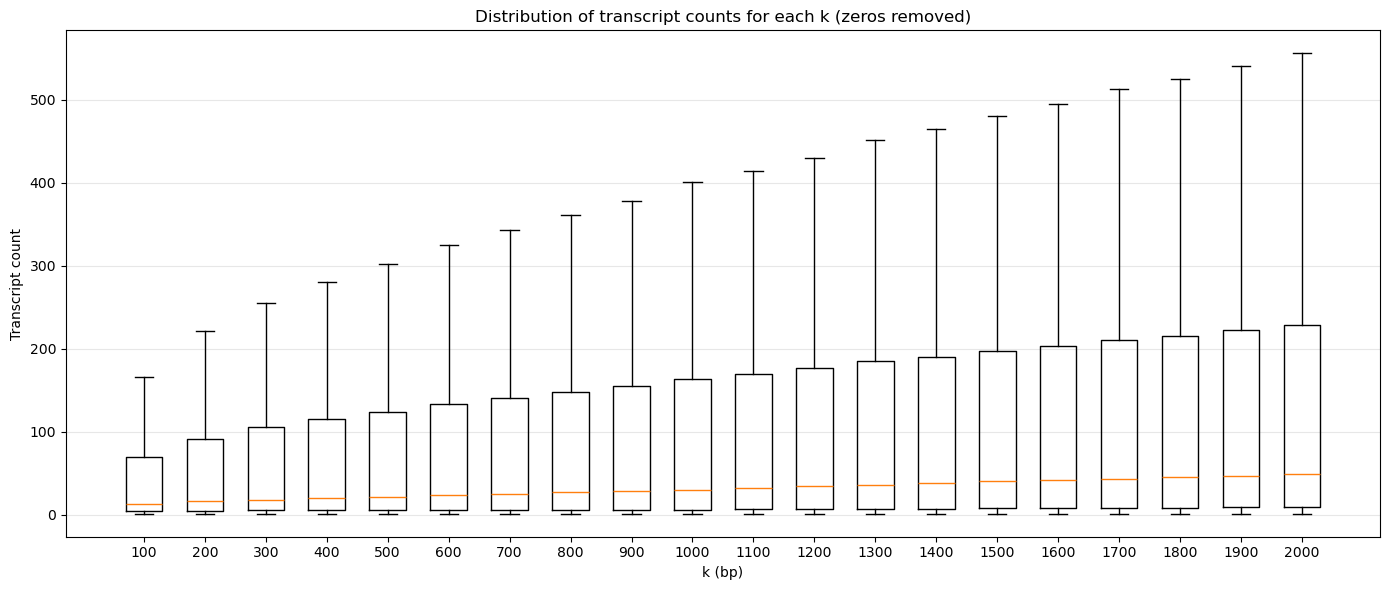

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Directory containing the TSV files
coverage_dir = Path('../data/coverage_spaceranger')

# Mapping: k -> {transcript_id -> summed_count}
counts = {}

# Loop through k values from 100 to 2000 in steps of 100
for k in range(100, 2100, 100):
    counts_k = {}
    tsv_file = coverage_dir / f'last_{k}_bp.tsv'
    if tsv_file.exists():
        # Read transcript-level counts for this k
        df = pd.read_csv(tsv_file, sep='\t', header=0, names=['transcript_id', 'count'])
        for transcript_id, group in df.groupby('transcript_id'):
            counts_k[transcript_id] = counts_k.get(transcript_id, 0) + group['count'].sum()
        
        counts[k] = counts_k
        print(f"Loaded {tsv_file.name}")
# Boxplots: transcript count distribution for each k (filter out count == 0)
k_values = sorted(counts.keys())
filtered_k_values = []
boxplot_data = []

for k in k_values:
    values = [v for v in counts[k].values() if v != 0]
    if values:
        filtered_k_values.append(k)
        boxplot_data.append(values)

if boxplot_data:
    fig, ax = plt.subplots(figsize=(14, 6), dpi=100)
    ax.boxplot(boxplot_data, positions=filtered_k_values, widths=60, showfliers=False)
    ax.set_xlabel('k (bp)')
    ax.set_ylabel('Transcript count')
    ax.set_title('Distribution of transcript counts for each k (zeros removed)')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('No non-zero transcript counts found to plot.')

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
    # Loop through k values from 100 to 2000 in steps of 100
def get_count_merged_regions(coverage_dir):
    counts = []
    for k in range(100, 2100, 100):
        matches = sorted(coverage_dir.glob(f"*last_{k}_bp_merged.tsv"))
        if not matches:
            continue

        tsv_file = matches[0]
        df = pd.read_csv(tsv_file, sep='\t', header=None, names=['chr', 'start', 'end', 'count'])
        counts.append(df['count'].sum())
    return counts 
spaceranger_counts = get_count_merged_regions(Path('../data/coverage_spaceranger_big'))
star_counts = get_count_merged_regions(Path('../data/coverage_tsv'))
human_counts = get_count_merged_regions(Path('../data/coverage_human'))
utr_star_counts = get_count_merged_regions(Path('../data/coverage_utr'))
print(len(utr_star_counts))

0


ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

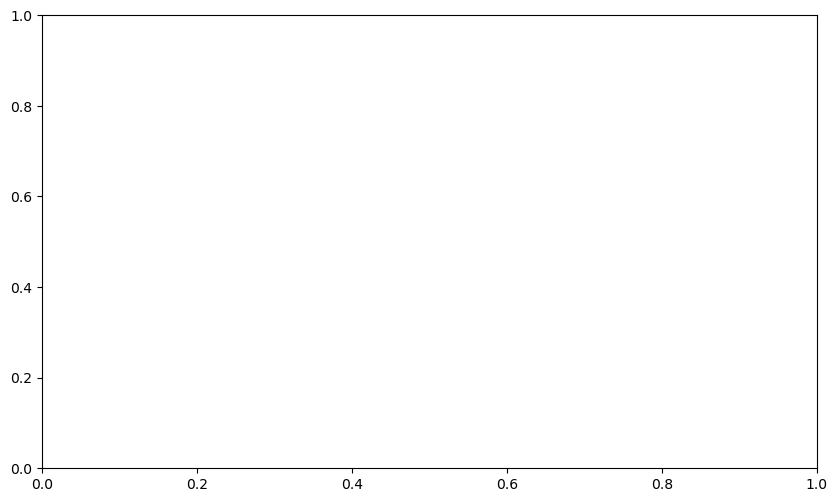

In [ ]:
fig = plt.figure(figsize=(10, 6), dpi = 100)
k_values = [k for k in range(100, 2100, 100)]
plt.plot(k_values, [c/263361661 * 100 for c in spaceranger_counts], marker='o')
plt.plot(k_values, [c/30708498 * 100 for c in star_counts], marker='o')
plt.plot(k_values, [c/124044099 * 100 for c in human_counts], marker='o')
plt.plot(k_values, [c/30708498 * 100 for c in utr_star_counts], marker='o')
#plt.plot#(k_values, human_counts, marker='o')
#plt.plot(k_values, spaceranger_counts, marker='o')
#plt.plot(k_values, star_counts, marker='o')
plt.xlabel('k (bp)')
plt.legend(['Spaceranger', 'STAR','Human', 'STAR UTR'])
plt.ylabel('percentage counts')
plt.grid(True, alpha=0.3)
plt.title('Read count across all transcripts for different k bases at the end of the transcript')
plt.show()

In [ ]:
import pandas as pd 
gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])
gtf.head()

/tmp/ipykernel_20310/2982498334.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])


,seqname,source,feature,start,end,score,strand,frame,attribute
0,1,ensembl,gene,226161299,226217308,.,-,.,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
1,1,ensembl,transcript,226188008,226217308,.,-,.,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
2,1,ensembl,exon,226217188,226217308,.,-,.,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
3,1,ensembl,CDS,226217188,226217253,.,-,0,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."
4,1,ensembl,start_codon,226217251,226217253,.,-,0,"gene_id ""ENSSSCG00000028996""; gene_version ""4""..."


In [ ]:
exons = gtf[gtf['feature'] == 'exon'].copy()
exons['transcript_id'] = exons['attribute'].str.extract(r'transcript_id "([^"]+)"')
bed_format = exons[['seqname', 'start', 'end', 'transcript_id', 'score', 'strand']].copy()
bed_format.loc[:, 'start'] = bed_format['start'] - 1
bed_format.drop(columns=['score'], inplace=True)
bed_format.head()
bed_format.to_csv('../data/exons_for_filtering.bed', sep='\t', header=False, index=False)

In [ ]:
# Sort by transcript_id AND genomic position
exons = exons.sort_values(["transcript_id", "seqname", "start", "end"])

introns = []
last_5_introns = []
transcripts_last_5_introns_bigger_than_10k = set()
for tx, group in exons.groupby("transcript_id"):
    if len(group) < 2:
        continue
    
    # Intron starts right after previous exon ends
    starts = group["end"].values[:-1] + 1
    # Intron ends right before next exon starts
    ends = group["start"].values[1:] - 1
    lengths = ends - starts + 1

    introns.extend(lengths)
    # Take only the last 5 introns (or fewer if transcript has less than 5)
    last_5_introns.extend(lengths[-5:])
 # Track transcripts with any intron > 10k bp in the last 5
    if any(x > 10000 for x in lengths[-5:]):
        transcripts_last_5_introns_bigger_than_10k.add(tx)

longer_then_10k = [x for x in last_5_introns if x > 10000]
average_intron_length = sum(last_5_introns) / len(last_5_introns)
print(f"Total introns (all): {len(introns)}")
print(f"Total introns (last 5 per transcript): {len(last_5_introns)}")
print(f"number Introns > 10k bp in the last 5 introns: {len(longer_then_10k)}")
print(f"Percentage > 10k bp: {len(longer_then_10k) / len(last_5_introns):.2%}")
print(f"Average intron length (last 5): {average_intron_length:.1f} bp")

NameError: name 'exons' is not defined

In [ ]:
transcripts = exons[exons["transcript_id"].isin(transcripts_last_5_introns_bigger_than_10k)]
transcripts.shape


NameError: name 'exons' is not defined

In [ ]:
last_500_bp_regions = pd.read_csv('../data/bedfiles/last_500_bp.bed', sep='\t', header=None, names=["chr", "start", "end", "transcript_id", "score", "strand"])
last_500_bp_regions.head()
intron = []
for tx, region in last_500_bp_regions.groupby('transcript_id'):
    if(len(region) < 2):
        continue
    # Intron starts right after previous exon ends
    starts = region["end"].values[:-1] + 1
    # Intron ends right before next exon starts
    ends = region["start"].values[1:] - 1
    lengths = ends - starts + 1
    introns.extend(lengths)

intron_series = pd.Series(introns)

# Disable scientific notation for this output
pd.options.display.float_format = '{:.2f}'.format
print(intron_series.describe())
# Reset to default
pd.reset_option('display.float_format')

FileNotFoundError: File b'../data/bedfiles/last_500_bp.bed' does not exist

In [ ]:
import pandas as pd 
gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])
utrs = gtf[gtf['feature'] == 'three_prime_utr'].copy()
utrs['transcript_id'] = utrs['attribute'].str.extract(r'transcript_id "([^"]+)"')
utrs['gene_id'] = utrs['attribute'].str.extract(r'gene_id "([^"]+)"')
lenghts= []
gene_mapping = {}
for tx, group in utrs.groupby("transcript_id"):
    length = 0
    for utr in group.itertuples():
        length += utr.end - utr.start + 1
    gene_mapping[tx] = group['gene_id'].iloc[0]
    lenghts.append(length)
#utrs['length'] = utrs['end'] - utrs['start'] + 1
#utrs['length'].describe()
lenghts_series = pd.Series(lenghts)
lenghts_series.describe()

/tmp/ipykernel_41300/3627101713.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv('../data/Sus_scrofa.Sscrofa11.1.gtf', sep='\t', comment='#', header=None, names=['seqname', 'source', 'feature', 'start', 'end', 'score', 'strand', 'frame', 'attribute'])


count    36510.000000
mean      1441.360422
std       1369.734274
min          1.000000
25%        410.000000
50%       1001.000000
75%       2070.750000
max      17391.000000
dtype: float64

In [ ]:
from scipy.io import mmread
import numpy as np
kallisto_dir = Path('/mnt/biocluster/praktikum/genprakt-ws25/gruppe_a/data/kallisto_run')

transcript_ids = []
with (kallisto_dir / 'utr_500bp'/ 'utr_last_500.fa').open() as fasta_handle:
    for line in fasta_handle:
        if line.startswith('>'):
            transcript_ids.append(line[1:].strip().split()[0])

ec_matrix = mmread(kallisto_dir /'utr_500bp' / 'output.mtx').tocsr()
ec_counts = np.asarray(ec_matrix.sum(axis=1)).ravel().astype(np.int64)
nonzero_ec_counts = {ec_idx: ec_counts[ec_idx] for ec_idx in np.flatnonzero(ec_counts)}

# Ambiguous equivalence-class counts are added to each compatible transcript.
transcript_totals = np.zeros(len(transcript_ids), dtype=np.int64)
with (kallisto_dir / 'utr_500bp' / 'output.ec.txt').open() as ec_handle:
    for line in ec_handle:
        ec_id_text, tx_index_text = line.rstrip().split('\t')
        ec_count = nonzero_ec_counts.get(int(ec_id_text))
        if ec_count is None:
            continue

        tx_indices = np.fromstring(tx_index_text, sep=',', dtype=np.int64)
        transcript_totals[tx_indices] += ec_count

transcript_count_matrix = pd.DataFrame(
    {
        'transcript_id': transcript_ids,
        'count': transcript_totals,
    }
)
transcript_count_matrix = transcript_count_matrix[transcript_count_matrix['count'] > 0].reset_index(drop=True)
transcript_count_matrix.head()


,transcript_id,count
0,ENSSSCT00000078291,2
1,ENSSSCT00000078294,7
2,ENSSSCT00000078296,4
3,ENSSSCT00000078299,2
4,ENSSSCT00000078280,3


In [22]:
from pathlib import Path
import pandas as pd

counts_dir = Path('/mnt/raidbio2/extstud/praktikum/genprakt-ws25/gruppe_a/data/feature_Counts')

def load_feature_counts_count_file(file_path):
    df = pd.read_csv(file_path, sep='\t', comment='#', header=0)
    return df.rename(columns={
        df.columns[0]: 'transcript_id',
        df.columns[-1]: 'counts',
    })

spaceranger_primary = load_feature_counts_count_file(
    counts_dir / 'spaceranger_primary.txt',
)
star_primary = load_feature_counts_count_file(
    counts_dir / 'star_primary.txt',
)
spaceranger_70p = load_feature_counts_count_file(
    counts_dir / 'spaceranger_70p.txt',
)
star_70p = load_feature_counts_count_file(
    counts_dir / 'star_70p.txt',
)
star_50p = load_feature_counts_count_file(
    counts_dir / 'star_50p.txt',
)
spaceranger_50p = load_feature_counts_count_file(
    counts_dir / 'spaceranger_50p.txt',
)
'''
star_min_40bp_overlap_counts_std = load_feature_counts_count_file(
    datapath / 'data' / 'feature_Counts' / 'minoveralp_40_bp.txt',
)
spaceranger_min_40bp_overlap_counts_std = load_feature_counts_count_file(
    datapath / 'data' / 'feature_Counts' / 'spaceranger_40_bp.txt',
)

spaceranger_min_70p_overlap_counts_std = load_feature_counts_count_file(
    datapath / 'data' / 'feature_Counts' / 'spaceranger_70.txt',
)
'''


"\nstar_min_40bp_overlap_counts_std = load_feature_counts_count_file(\n    datapath / 'data' / 'feature_Counts' / 'minoveralp_40_bp.txt',\n)\nspaceranger_min_40bp_overlap_counts_std = load_feature_counts_count_file(\n    datapath / 'data' / 'feature_Counts' / 'spaceranger_40_bp.txt',\n)\n\nspaceranger_min_70p_overlap_counts_std = load_feature_counts_count_file(\n    datapath / 'data' / 'feature_Counts' / 'spaceranger_70.txt',\n)\n"

In [23]:
import matplotlib.pyplot as plt

def plot_count_correlation(
    df1,
    df2,
    id_col="transcript_id",
    count_col="counts",
    label1="Dataset 1",
    label2="Dataset 2",
    log_scale=True,
):
    """
    Plot correlation between two count tables.

    Expected columns in both dataframes:
      - id_col (default: transcript_id)
      - count_col (default: counts)
    """
    a = df1[[id_col, count_col]].rename(columns={count_col: f"count_{label1}"})
    b = df2[[id_col, count_col]].rename(columns={count_col: f"count_{label2}"})

    merged = a.merge(b, on=id_col, how="inner")

    if log_scale:
        merged = merged[(merged[f"count_{label1}"] > 0) & (merged[f"count_{label2}"] > 0)].copy()

    corr = merged[f"count_{label1}"].corr(merged[f"count_{label2}"])
    print(f"Pearson correlation ({label1} vs {label2}): {corr:.4f}")

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(merged[f"count_{label1}"], merged[f"count_{label2}"], alpha=0.5, s=10)

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")

    ax.set_xlabel(f"{label1} count")
    ax.set_ylabel(f"{label2} count")
    ax.set_title(f"{label1} vs {label2}\nCorrelation: {corr:.4f}")
    ax.grid(True, alpha=0.3)

    min_val = min(merged[f"count_{label1}"].min(), merged[f"count_{label2}"].min())
    max_val = max(merged[f"count_{label1}"].max(), merged[f"count_{label2}"].max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", alpha=0.6, label="y=x")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return corr, merged

Pearson correlation (STAR 70% Overlap vs Spaceranger 70% Overlap): 1.0000


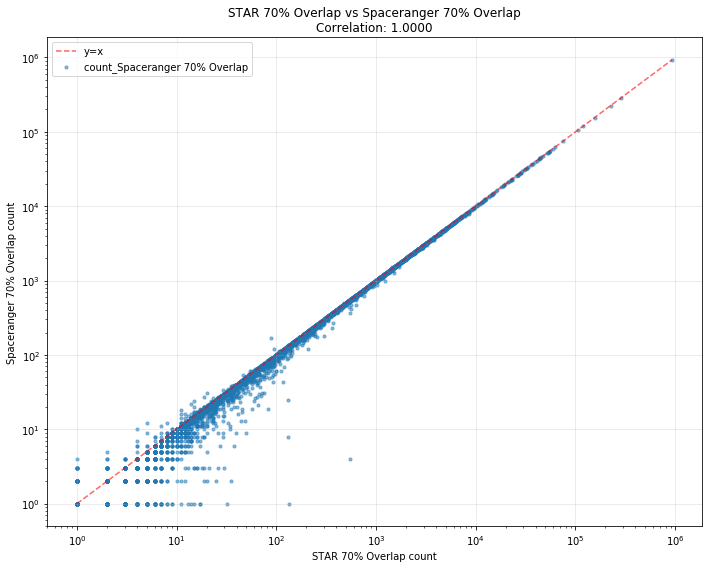

Pearson correlation (STAR 50% Overlap vs Spaceranger 50% Overlap): 0.9844


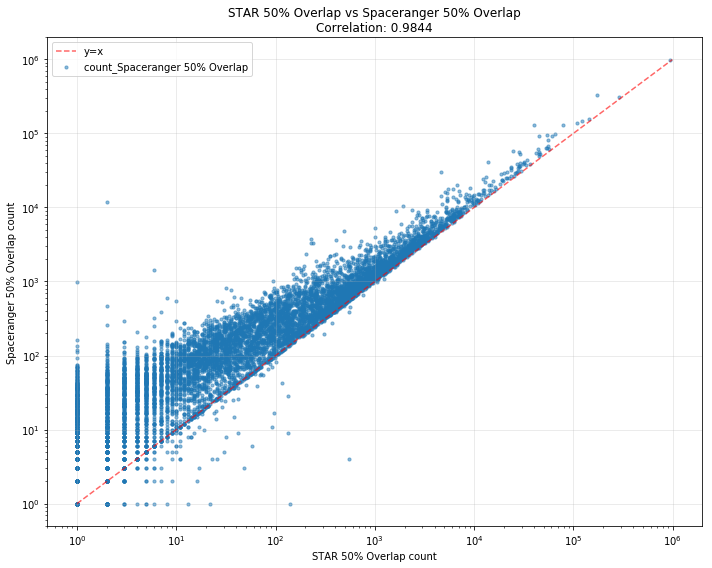

(0.9843767385596841,
             transcript_id  count_STAR 50% Overlap  \
 16     ENSSSCT00000065225                     234   
 17     ENSSSCT00000005806                      17   
 31     ENSSSCT00000104224                      10   
 33     ENSSSCT00000045630                      80   
 34     ENSSSCT00000083992                     117   
 43     ENSSSCT00000004805                       4   
 45     ENSSSCT00000042299                      15   
 49     ENSSSCT00000074211                       6   
 50     ENSSSCT00000004710                      42   
 54     ENSSSCT00000004808                      36   
 58     ENSSSCT00000053219                       6   
 60     ENSSSCT00000037177                       1   
 66     ENSSSCT00000050062                       2   
 85     ENSSSCT00000026265                     113   
 87     ENSSSCT00000005799                    1427   
 100    ENSSSCT00000052025                       9   
 101    ENSSSCT00000005552                       1   
 105   

In [24]:
# Run the function from the last cell on all requested comparisons
'''
plot_count_correlation(
    star_primary,
    spaceranger_primary,
    label1="STAR Primary",
    label2="Spaceranger Primary",
)
plot_count_correlation(
    spaceranger_primary,
    spaceranger_70p,
    label1="Spaceranger Primary",
    label2="Spaceranger 70% Overlap",
)

correlation, df = plot_count_correlation(
    star_primary,
    spaceranger_70p,
    label1="STAR Primary",
    label2="Spaceranger 70% Overlap",
)
'''

correlation, df = plot_count_correlation(
    star_70p,
    spaceranger_70p,
    label1="STAR 70% Overlap",
    label2="Spaceranger 70% Overlap",
)
plot_count_correlation(
    star_50p,
    spaceranger_50p,
    label1="STAR 50% Overlap",
    label2="Spaceranger 50% Overlap",
)

In [25]:
df.head()
candidate = df[(df['count_STAR 70% Overlap'] >1e2) & (df['count_STAR 70% Overlap'] < 1e3) & (df['count_Spaceranger 70% Overlap'] < 10)]
candidate.shape
candidate.head(20)

,transcript_id,count_STAR 70% Overlap,count_Spaceranger 70% Overlap
30091,ENSSSCT00000029731,132,8
38213,ENSSSCT00000101764,134,1
49637,ENSSSCT00000018279,551,4


In [26]:
transcript = df[df['transcript_id']=='ENSSSCT00000099229']
print(transcript)

            transcript_id  count_STAR 70% Overlap  \
11854  ENSSSCT00000099229                     130   

       count_Spaceranger 70% Overlap  
11854                             25  


Pearson correlation (STAR Gene Level vs Spaceranger Gene Level): 0.9864


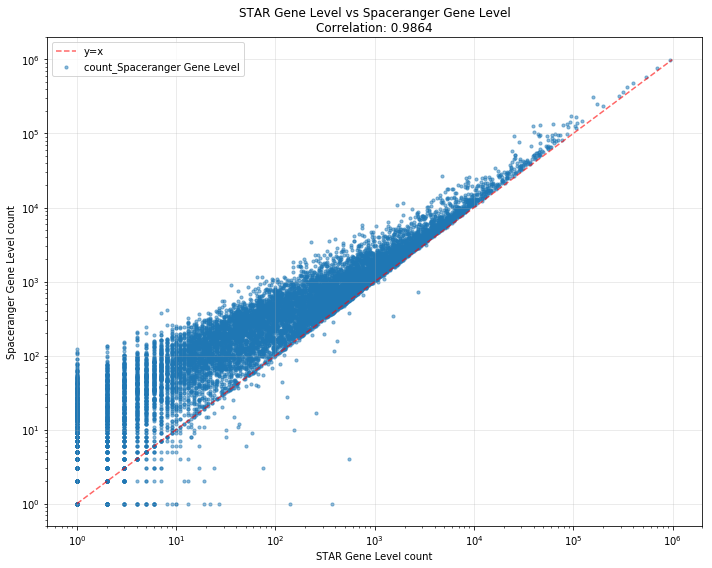

(0.9863670013827102,
             transcript_id  count_STAR Gene Level  count_Spaceranger Gene Level
 0      ENSSSCG00000028996                      1                             9
 1      ENSSSCG00000005267                   3059                          7733
 4      ENSSSCG00000031382                    234                           383
 5      ENSSSCG00000005271                     17                           195
 7      ENSSSCG00000005273                    402                           961
 9      ENSSSCG00000023520                    197                           337
 10     ENSSSCG00000057774                     10                            22
 11     ENSSSCG00000037277                     94                           361
 12     ENSSSCG00000005277                    117                           193
 14     ENSSSCG00000004349                     65                           307
 15     ENSSSCG00000004272                     54                           329
 16     ENSSSCG0000

In [27]:
star_gene_level = load_feature_counts_count_file(
    counts_dir / 'star_gene.txt',
)
spaceranger_gene_level = load_feature_counts_count_file(
    counts_dir / 'spaceranger_gene.txt',
)
plot_count_correlation(
    star_gene_level,
    spaceranger_gene_level,
    label1="STAR Gene Level",
    label2="Spaceranger Gene Level",
)

Pearson correlation (STAR Gene Level 70% Overlap vs Spaceranger Gene Level 70% Overlap): 1.0000


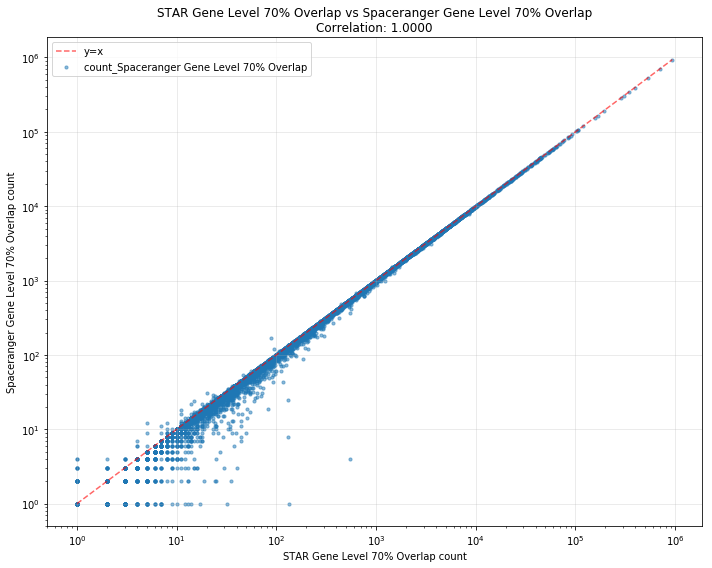

(0.9999893741844681,
             transcript_id  count_STAR Gene Level 70% Overlap  \
 0      ENSSSCG00000028996                                  1   
 1      ENSSSCG00000005267                               2861   
 4      ENSSSCG00000031382                                229   
 5      ENSSSCG00000005271                                  5   
 7      ENSSSCG00000005273                                368   
 9      ENSSSCG00000023520                                153   
 10     ENSSSCG00000057774                                  9   
 11     ENSSSCG00000037277                                 84   
 12     ENSSSCG00000005277                                114   
 14     ENSSSCG00000004349                                 65   
 15     ENSSSCG00000004272                                 33   
 16     ENSSSCG00000037594                                 49   
 17     ENSSSCG00000044472                                  1   
 18     ENSSSCG00000004261                                 42   
 20 

In [28]:
star_70p_gene_level = load_feature_counts_count_file(
    counts_dir / 'star_gene_70p.txt',)
spaceranger_70p_gene_level = load_feature_counts_count_file(
    counts_dir / 'spaceranger_gene_70p.txt',)
plot_count_correlation(
    star_70p_gene_level,
    spaceranger_70p_gene_level,
    label1="STAR Gene Level 70% Overlap",
    label2="Spaceranger Gene Level 70% Overlap",
)



Pearson correlation (Spaceranger Primary vs Minimap Counts): 0.9888


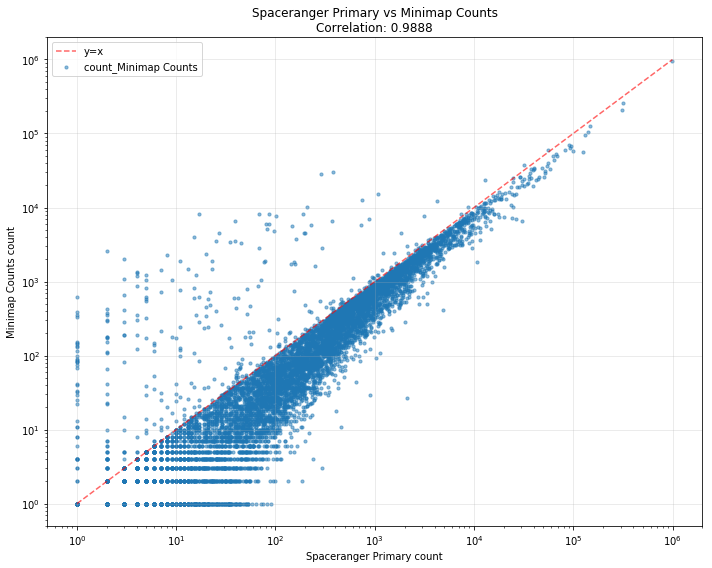

(0.9888324279017793,
             transcript_id  count_Spaceranger Primary  count_Minimap Counts
 8      ENSSSCT00000005802                          4                     1
 16     ENSSSCT00000065225                        383                   294
 17     ENSSSCT00000005806                        195                    49
 31     ENSSSCT00000104224                         22                   730
 33     ENSSSCT00000045630                        290                    87
 34     ENSSSCT00000083992                        193                    78
 43     ENSSSCT00000004805                         59                    20
 45     ENSSSCT00000042299                         55                    34
 49     ENSSSCT00000074211                        104                    28
 50     ENSSSCT00000004710                        160                  3806
 54     ENSSSCT00000004808                         59                    41
 58     ENSSSCT00000053219                        110              

In [29]:
minimap_counts = load_feature_counts_count_file(
    counts_dir / 'minimap_counts.txt',
)
plot_count_correlation(
    spaceranger_primary,
    minimap_counts,
    label1="Spaceranger Primary",
    label2="Minimap Counts",
)

Pearson correlation (Spaceranger 70% Overlap vs Minimap 70% Overlap): 0.9957


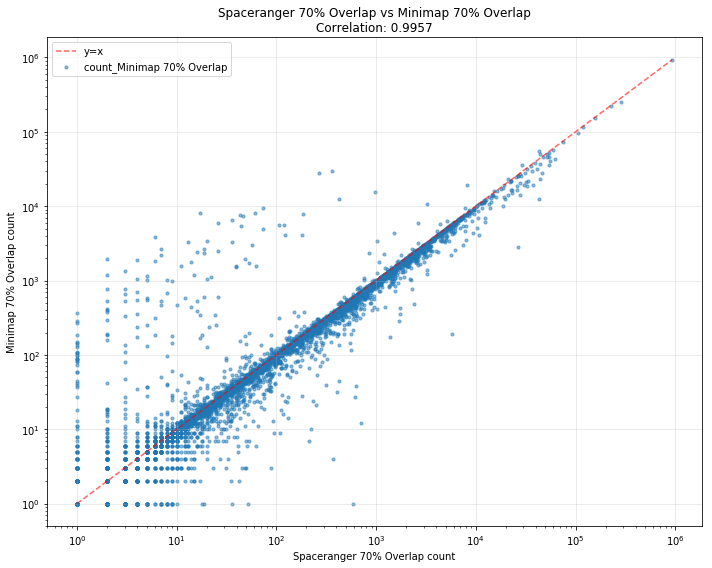

In [30]:
minimap_70p = load_feature_counts_count_file(
    counts_dir / 'minimap_70p.txt',
)
cor, spaceranger_minimap_70p = plot_count_correlation(
    spaceranger_70p,
    minimap_70p,
    label1="Spaceranger 70% Overlap",
    label2="Minimap 70% Overlap",
)

In [31]:
spaceranger_minimap_70p.head()
spaceranger_minimap_70p['difference']= (spaceranger_minimap_70p['count_Spaceranger 70% Overlap'] - spaceranger_minimap_70p['count_Minimap 70% Overlap']).abs()
spaceranger_minimap_70p = spaceranger_minimap_70p.sort_values('difference', ascending=False)
spaceranger_minimap_70p.head(20)

,transcript_id,count_Spaceranger 70% Overlap,count_Minimap 70% Overlap,difference
53672,ENSSSCT00000038762,283485,248539,34946
4316,ENSSSCT00000044885,43263,12681,30582
57256,ENSSSCT00000106129,361,29434,29073
32384,ENSSSCT00000024482,266,28040,27774
488,ENSSSCT00000005482,26688,2856,23832
14031,ENSSSCT00000024602,44061,23424,20637
12954,ENSSSCT00000003515,62578,42491,20087
37454,ENSSSCT00000043834,37111,19107,18004
11240,ENSSSCT00000004346,45740,27962,17778
13245,ENSSSCT00000093057,53744,36188,17556


In [34]:
gene_and_transcript_counts = pd.read_csv('/mnt/raidbio2/extstud/praktikum/genprakt-ws25/gruppe_a/sccount/counts_genes.tsv', sep='\t', header=None, names=['id', 'count'])
star_gene_counts = spaceranger_70p_gene_level[['transcript_id', 'counts']].rename(columns={'transcript_id': 'id', 'counts': 'count'})
merged_genes = gene_and_transcript_counts.merge(star_gene_counts, 'inner', on='id', suffixes=('_ours', '_star_70p'))
merged_genes.head()

,id,count_ours,count_star_70p
0,ENSSSCG00000042915,84,0
1,ENSSSCG00000050757,380,0
2,ENSSSCG00000015067,889,1198
3,ENSSSCG00000046587,6,0
4,ENSSSCG00000002311,47,608


Pearson correlation (merged_genes): 0.5664


ValueError: provided too many kwargs, can only pass {'basex', 'subsx', nonposx'} or {'basey', 'subsy', nonposy'}.  You passed {'base': 10}

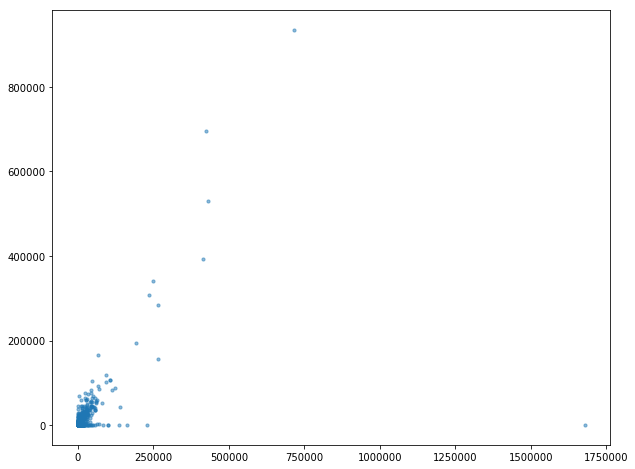

In [35]:

plot_df = merged_genes[(merged_genes["count_ours"] > 0) & (merged_genes["count_star_70p"] > 0)].copy()

corr = plot_df["count_ours"].corr(plot_df["count_star_70p"])
print(f"Pearson correlation (merged_genes): {corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(plot_df["count_ours"], plot_df["count_star_70p"], alpha=0.5, s=10)

ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)
ax.set_xlabel("count_ours")
ax.set_ylabel("count_star_70p")
ax.set_title(f"merged_genes: count_ours vs count_star_70p\nCorrelation: {corr:.4f}")
ax.grid(True, alpha=0.3)

min_val = min(plot_df["count_ours"].min(), plot_df["count_star_70p"].min())
max_val = max(plot_df["count_ours"].max(), plot_df["count_star_70p"].max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", alpha=0.6, label="y=x")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
gene_counts = pd.read_csv('/mnt/raidbio2/extstud/praktikum/genprakt-ws25/gruppe_a/sccount/counts.tsv', sep = '\t', header = None, names=['id', 'count'])
spaceranger_gene_counts = spaceranger_70p_gene_level[['transcript_id', 'counts']].rename(columns={'transcript_id': 'id', 'counts': 'count'})
merged_genes = gene_counts.merge(spaceranger_gene_counts, 'inner', on='id', suffixes=('_ours', '_spaceranger_70p'))
merged_transcript_counts = gene_counts.merge(spaceranger_70p[['transcript_id', 'counts']].rename(columns={'transcript_id': 'id', 'counts': 'count'}), 'inner', on='id', suffixes=('_ours', '_spaceranger_70p'))
merged_transcript_counts.head()

NameError: name 'spaceranger_70p_gene_level' is not defined

Pearson correlation (merged_genes): 0.5664


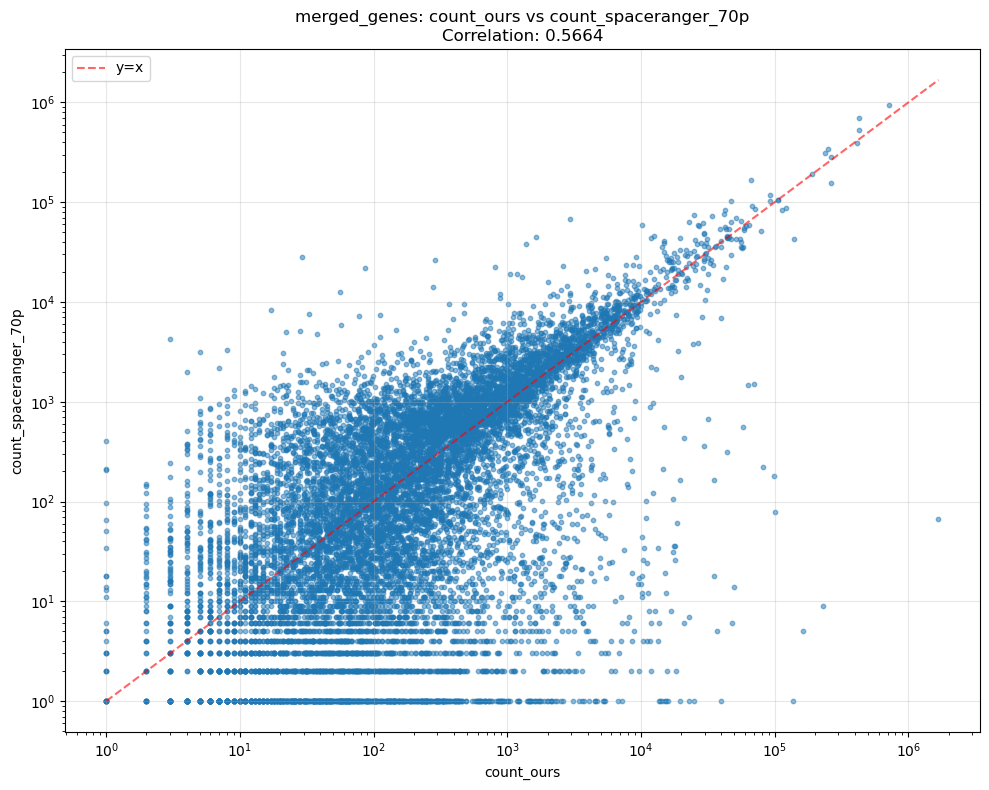

In [ ]:

plot_df = merged_genes[(merged_genes["count_ours"] > 0) & (merged_genes["count_spaceranger_70p"] > 0)].copy()

corr = plot_df["count_ours"].corr(plot_df["count_spaceranger_70p"])
print(f"Pearson correlation (merged_genes): {corr:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(plot_df["count_ours"], plot_df["count_spaceranger_70p"], alpha=0.5, s=10)

ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)
ax.set_xlabel("count_ours")
ax.set_ylabel("count_spaceranger_70p")
ax.set_title(f"merged_genes: count_ours vs count_spaceranger_70p\nCorrelation: {corr:.4f}")
ax.grid(True, alpha=0.3)

min_val = min(plot_df["count_ours"].min(), plot_df["count_spaceranger_70p"].min())
max_val = max(plot_df["count_ours"].max(), plot_df["count_spaceranger_70p"].max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", alpha=0.6, label="y=x")
ax.legend()

plt.tight_layout()
plt.show()